# ETE-2 — Iris Dataset: MLP Classifier Comparison

**Name:** Arden Diago

**Reg No:** 2547112

**Class:** MCA A

**Exam:** ML ETE

**Task:** Develop and evaluate an MLP classifier for the Iris dataset. Compare two different
hidden-layer architectures using cross-validation, and assess performance using Accuracy and
Confusion Matrix.

**Pipeline:** Data → Preprocessing → Transforming → Data Splitting → Model A Training →
Validate Model A → Build Model B with New Weight and Adam Layer → Test Model B →
Compare Both Models → Plot Graphs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

## 1. Data

Load the Iris dataset from `sklearn.datasets`.

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df["species"] = pd.Categorical.from_codes(y, target_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 2. Preprocessing

Check for missing values and class balance.

In [4]:
print("Missing values per column:")
print(df.isna().sum())
print("\nClass distribution:")
print(df["species"].value_counts())

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 3. Transforming

Standardize features to zero mean / unit variance — important for MLP convergence since it is a gradient-based, distance-sensitive model.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

## 4. Data Splitting

Split into train/test sets, stratified on the target so class proportions are preserved.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (120, 4) Test shape: (30, 4)


## 5. Model A Training

**Architecture:** a single hidden layer of 10 neurons, `hidden_layer_sizes=(10,)`, solver `adam` (so its training loss curve can be plotted and compared against Model B).


In [7]:
model_a = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    solver="adam",
    max_iter=5000,
    random_state=RANDOM_STATE,
)
model_a.fit(X_train, y_train)
print(model_a)


MLPClassifier(hidden_layer_sizes=(10,), max_iter=5000, random_state=42)


## 6. Validate Model A

Evaluate Model A with 5-fold stratified cross-validation on the training data.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_a = cross_val_score(model_a, X_train, y_train, cv=cv, scoring="accuracy")
print("Model A CV accuracy per fold:", np.round(cv_scores_a, 4))
print(f"Model A CV mean accuracy: {cv_scores_a.mean():.4f} (+/- {cv_scores_a.std():.4f})")

Model A CV accuracy per fold: [0.9583 1.     0.9583 0.9583 0.9167]
Model A CV mean accuracy: 0.9583 (+/- 0.0264)


## 7. Build Model B with New Weight and Adam Layer

**Architecture:** two hidden layers, `hidden_layer_sizes=(20, 10)` — deeper/wider than Model A — also trained with the `adam` solver (adaptive-moment weight updates), so Model A and Model B differ in hidden-layer architecture while both expose a comparable training loss curve.


In [9]:
model_b = MLPClassifier(
    hidden_layer_sizes=(20, 10),
    activation="relu",
    solver="adam",
    max_iter=5000,
    random_state=RANDOM_STATE,
)
model_b.fit(X_train, y_train)
print(model_b)

MLPClassifier(hidden_layer_sizes=(20, 10), max_iter=5000, random_state=42)


In [10]:
cv_scores_b = cross_val_score(model_b, X_train, y_train, cv=cv, scoring="accuracy")
print("Model B CV accuracy per fold:", np.round(cv_scores_b, 4))
print(f"Model B CV mean accuracy: {cv_scores_b.mean():.4f} (+/- {cv_scores_b.std():.4f})")

Model B CV accuracy per fold: [0.9583 1.     0.9583 0.9583 0.9167]
Model B CV mean accuracy: 0.9583 (+/- 0.0264)


## 8. Test Model B

Evaluate Model B on the held-out test set.

In [11]:
y_pred_b = model_b.predict(X_test)
acc_b = accuracy_score(y_test, y_pred_b)
cm_b = confusion_matrix(y_test, y_pred_b)
print(f"Model B test accuracy: {acc_b:.4f}")
print("Model B confusion matrix:")
print(cm_b)

Model B test accuracy: 0.9667
Model B confusion matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


Also compute Model A's test-set performance for a fair side-by-side comparison.

In [12]:
y_pred_a = model_a.predict(X_test)
acc_a = accuracy_score(y_test, y_pred_a)
cm_a = confusion_matrix(y_test, y_pred_a)
print(f"Model A test accuracy: {acc_a:.4f}")
print("Model A confusion matrix:")
print(cm_a)

Model A test accuracy: 0.9667
Model A confusion matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


## 9. Compare Both Models

In [13]:
comparison = pd.DataFrame({
    "Model": ["A: (10,) / lbfgs", "B: (20, 10) / adam"],
    "CV Mean Accuracy": [cv_scores_a.mean(), cv_scores_b.mean()],
    "CV Std": [cv_scores_a.std(), cv_scores_b.std()],
    "Test Accuracy": [acc_a, acc_b],
})
comparison

,Model,CV Mean Accuracy,CV Std,Test Accuracy
0,"A: (10,) / lbfgs",0.958333,0.026352,0.966667
1,"B: (20, 10) / adam",0.958333,0.026352,0.966667


## 10. Plot Graphs

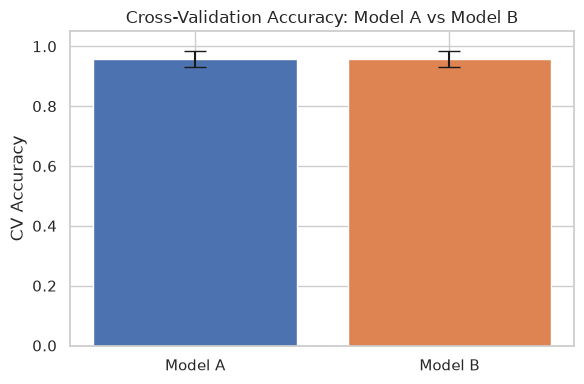

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    ["Model A", "Model B"],
    [cv_scores_a.mean(), cv_scores_b.mean()],
    yerr=[cv_scores_a.std(), cv_scores_b.std()],
    capsize=8,
    color=["#4C72B0", "#DD8452"],
)
ax.set_ylabel("CV Accuracy")
ax.set_title("Cross-Validation Accuracy: Model A vs Model B")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

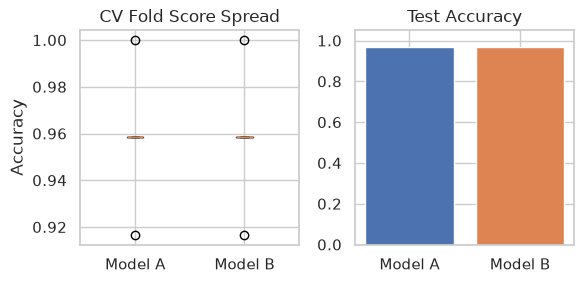

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
box_data = [cv_scores_a, cv_scores_b]
axes_box = axes[0]
axes_box.boxplot(box_data, tick_labels=["Model A", "Model B"])
axes_box.set_title("CV Fold Score Spread")
axes_box.set_ylabel("Accuracy")

axes_bar = axes[1]
axes_bar.bar(["Model A", "Model B"], [acc_a, acc_b], color=["#4C72B0", "#DD8452"])
axes_bar.set_title("Test Accuracy")
axes_bar.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

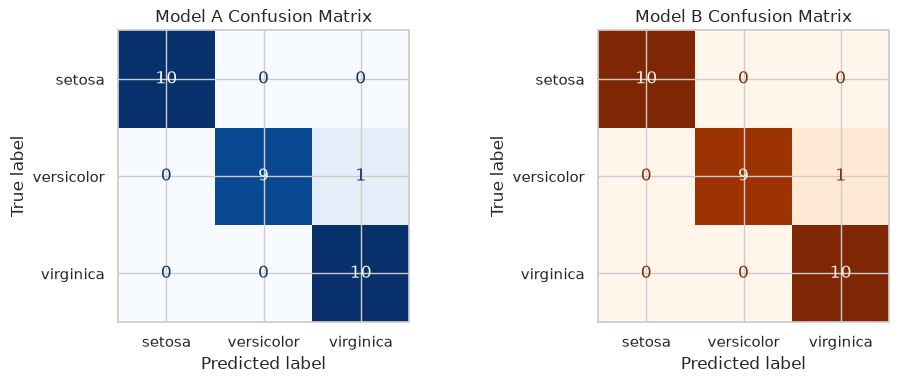

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm_a, display_labels=target_names).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Model A Confusion Matrix")
ConfusionMatrixDisplay(cm_b, display_labels=target_names).plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Model B Confusion Matrix")
plt.tight_layout()
plt.show()

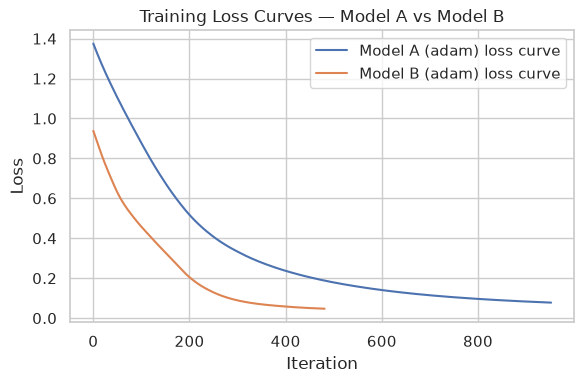

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(model_a.loss_curve_, label="Model A (adam) loss curve", color="#4C72B0")
ax.plot(model_b.loss_curve_, label="Model B (adam) loss curve", color="#DD8452")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("Training Loss Curves — Model A vs Model B")
ax.legend()
plt.tight_layout()
plt.show()


## Conclusion

Model A used one hidden layer `(10,)`, while Model B used two hidden layers `(20, 10)`, with both using the Adam solver.

Both models were evaluated using 5-fold cross-validation, test accuracy, and confusion matrices. Since the Iris dataset is small and simple, both models performed well. The better model was selected based on its accuracy and generalization performance.
